<h1>Table des matières<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Rappel-théorique" data-toc-modified-id="Rappel-théorique-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Rappel théorique</a></span></li><li><span><a href="#Exercice-1-:-Modèle-uniforme-en-espace" data-toc-modified-id="Exercice-1-:-Modèle-uniforme-en-espace-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Exercice 1 : Modèle uniforme en espace</a></span><ul class="toc-item"><li><span><a href="#Question-1-:-Modèle-de-Malthus" data-toc-modified-id="Question-1-:-Modèle-de-Malthus-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Question 1 : Modèle de Malthus</a></span></li><li><span><a href="#Question-2-:-Ordre-de-convergence-numérique" data-toc-modified-id="Question-2-:-Ordre-de-convergence-numérique-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Question 2 : Ordre de convergence numérique</a></span></li><li><span><a href="#Question-3-:-Modèle-de-Verhulst" data-toc-modified-id="Question-3-:-Modèle-de-Verhulst-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Question 3 : Modèle de Verhulst</a></span></li></ul></li><li><span><a href="#Exercice-2.-Modèle-non-uniforme-en-espace" data-toc-modified-id="Exercice-2.-Modèle-non-uniforme-en-espace-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Exercice 2. Modèle non uniforme en espace</a></span><ul class="toc-item"><li><span><a href="#Question-1-:-Programmation-et-test-de-la-méthode-d'Euler-explicite" data-toc-modified-id="Question-1-:-Programmation-et-test-de-la-méthode-d'Euler-explicite-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Question 1 : Programmation et test de la méthode d'Euler explicite</a></span></li><li><span><a href="#Question-2-:-Résolution-au-fil-du-temps" data-toc-modified-id="Question-2-:-Résolution-au-fil-du-temps-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Question 2 : Résolution au fil du temps</a></span></li><li><span><a href="#Question-3-:-Instabilité-numérique" data-toc-modified-id="Question-3-:-Instabilité-numérique-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Question 3 : Instabilité numérique</a></span></li><li><span><a href="#Question-4-:-Résolution-par-méthode-d'Euler-implicite" data-toc-modified-id="Question-4-:-Résolution-par-méthode-d'Euler-implicite-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Question 4 : Résolution par méthode d'Euler implicite</a></span></li></ul></li></ul></div>

# L3 Analyse Numérique – TP6

Dans ce TP, nous étudions des méthodes numériques pour le calcul approché de solutions d'équations différentielles. 
Certaines notions sont issues du cours Équations Différentielles ou Analyse Appliquée du second semestre et seront rappelées dans l'énoncé (voir ci-dessous le paragraphe "Rappel théorique").

L'objet de l'étude porte sur quelques modèles mathématiques pour décrire l'évolution d'une population de poissons dans un grand canal. Nous supposons connue la densité de population à un instant $t_0$ et nous souhaitons prévoir comment la population est susceptible d'évoluer au cours du temps. 


In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Rappel théorique 

<div class="alert alert-block alert-success">
Quelques notions rudimentaires issues du 
    <b><a href="https://foad.univ-rennes.fr/pluginfile.php/2467003/mod_folder/content/0/A.%20Polycopi%C3%A9s%20de%20cours/Chapitre5.pdf?forcedownload=1">Poycopié du Chapitre 5</a></b>
</div>



Considérons le problème de Cauchy autonome suivant:

$$
\begin{aligned}
	y' &= f(y)\\
	y(t_0) &= y^0.
\end{aligned}
$$

où $f$ est une fonction définie sur un ouvert $U$ de $\mathbb{R}^{d}$, à valeurs dans $\mathbb{R}^d$, $y^0 \in U$ est la condition initiale prescrite à l'instant $t_0$.

Sous l'hypothèse que $f$ est continue sur $U$ et *localement lipschitzienne*, le **théorème de Cauchy-Lipschitz** garantit l'existence d'une unique solution maximale $y$, définie et continûment différentiable sur un intervalle $I$ ouvert contenant $t_0$.

Plus particulièrement, lorsque $f\in\mathcal{C}^1(\mathbb{R}^d;\mathbb{R}^d)$ admet une différentielle bornée, alors toutes les solutions maximales de l'équation différentielle sont globales, i.e. définies sur $\mathbb{R}$ tout entier, et sont entièrement déterminées par la valeur $y^0$ prise en $t_0=0$.

En intégrant le problème de Cauchy entre deux instants $t$ et $t+h$ où $h>0$, la solution $y$ satisfait à la formulation:

$$
y(t+h)=y(t)+\int_t^{t+h} f(y(s))\mathrm{d} s.
$$

Les méthodes numériques les plus standards pour résoudre le problème de Cauchy sont obtenues sur la base d'une formule d'approximation de l'intégrale précédente par une méthode de quadrature.

La méthode d'**Euler explicite** détermine par exemple une suite d'instants $(t_i)_{i\geq 0}$ et des approximations $y_i\in\mathbb{R}^d$ de la solution exacte évaluée à ces instants $y(t_i)$. Elle se base sur une approximation de l'intégrale précédente par l'approximation des rectangles à gauche. La relation de récurrence prend alors la forme:
$$
\begin{aligned}
&y_{0} = y^0,\\
&\forall i\in\mathbb{N},\quad y_{i+1} = y_{i}+h_{i}f(y_{i}),\\
&\forall i\in\mathbb{N},\quad t_{i+1} = t_{i}+h_{i}.
\end{aligned}
$$

Typiquement, la résolution approchée sur un intervalle de temps $[0,T]$ est faite de la façon suivante. On fixe un entier $N$ et le pas $h_i$ est alors choisi indépendant de l'entier $i$ et égal à $h=T/N$ pour tout $i$, $0\leq i\leq N$. L'approximation se fait alors aux points de la subdivision uniforme $0=t_0<t_1<\dots<t_{N-1}<t_{N}=T$, avec $t_i=ih$.

## Exercice 1 : Modèle uniforme en espace

Dans un premier temps, on considère que la population de poissons se répartit uniformément dans le canal, et on s'intéresse aux variations de la densité $y(t)$ de poissons dans le canal. Par commodité, on normalise l'inconnue $y$, au sens où on suppose qu'à l'instant initial la densité vaut $y_0 = 1$.

### Question 1 : Modèle de Malthus

On s'intéresse ici à un modèle proposé par Malthus. Selon ce modèle, le nombre de naissances et le nombre de décès entre les instants $t$ et $t+\Delta t$ sont proportionnels à la taille de la population de poissons à l'instant $t$. Ce modèle conduit donc à une équation différentielle linéaire

$$y' = ay$$

Si $a>0$, la population croît, si $a<0$ elle décroît. 

Programmer la méthode d'Euler explicite sur l'exemple élémentaire : $y'=-10y$ avec la donnée de Cauchy $(t_0,y^0)=(0,1)$ sur l'intervalle de temps $[0,2.5]$.  
Comparer graphiquement la solution exacte $y(t)$ aux solutions approchées obtenues pour des valeurs de l'entier $N$ successivement dans $\{15,30,60,120\}$.

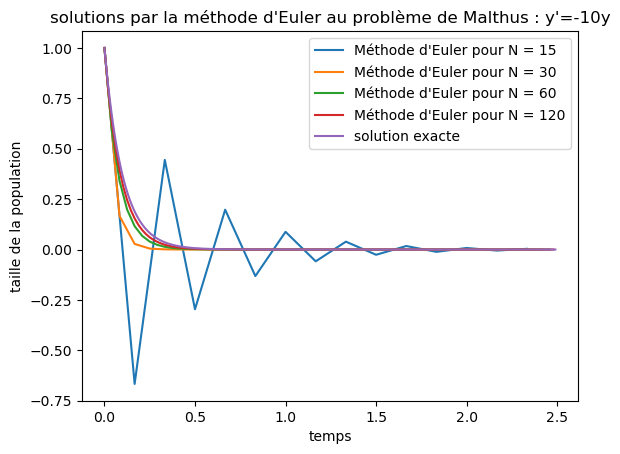

In [8]:
from math import *

y_0=1
for N in [15,30,60,120]:
    h=2.5/N
    x=np.arange(0,2.5,h)
    y=[y_0]
    for i in range(N-1):
        y.append(y[i]+-10*h*y[i])
    plt.plot(x,y,label="Méthode d'Euler pour N = "+str(N))
    
plt.plot(np.arange(0,2.5,0.01),[exp(-10*a) for a in np.arange(0,2.5,0.01)],label = "solution exacte")
plt.legend()
plt.title("solutions par la méthode d'Euler au problème de Malthus : y'=-10y")
plt.ylabel("taille de la population")
plt.xlabel("temps")
plt.show()

### Question 2 : Ordre de convergence numérique

Vérifier expérimentalement que la convergence de la méthode d'Euler explicite est, sur l'exemple précédent, au moins d'ordre $1$ au sens où il existe une constante $C$ (qui en fait ne dépend que de $y^0$, $f$ et $T$) telle que si on note $h=\sup_{i}(t_{i+1}-t_{i})$, on a:

$$\sup_{0\leq i\leq N}\vert y(t_i)-y_i\vert \leq Ch.$$

On pourra choisir successivement des valeurs de $N$ de la forme $[(2.2)^3],[(2.2)^4],\dots,[(2.2)^9]$ où le crochet désigne la partie entière et représenter l'erreur dans des échelles logarithmiques.

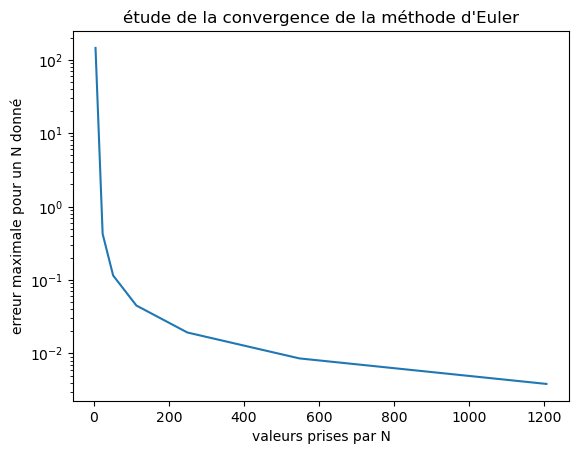

In [17]:
def f(x):
    return exp(-10*x)


y_0=1
errlist=[]
for N in [floor((2.2)**a) for a in [2,4,5,6,7,8,9]]:
    h=2.5/N
    x=np.arange(0,2.5,h)
    y=[y_0]
    errormax=f(0)-y_0
    for i in range(N-1):
        y.append(y[i]+-10*h*y[i])
        if errormax<abs(y[i+1]-f(x[i+1])):
            errormax = abs(y[i+1]-f(x[i+1]))
    errlist.append(errormax)
    
plt.plot([floor((2.2)**a) for a in [2,4,5,6,7,8,9]],errlist)
plt.xlabel("valeurs prises par N")
plt.ylabel("erreur maximale pour un N donné")
plt.title("étude de la convergence de la méthode d'Euler")
plt.yscale('log')
plt.show()


### Question 3 : Modèle de Verhulst

Dans le cas $a>0$, le modèle de Malthus conduit à une croissance exponentielle de la population. En pratique, une telle croissance n'est pas réaliste à moyen terme : la compétition pour la nourriture, le risque d'épidémies, etc, conduisent à une saturation et un ralentissement de la croissance. Verhulst propose donc de remplacer le modèle de Malthus par un modèle aussi appelé "modèle logistique", où la densité de population vérifie l'équation différentielle $y'= ay(1-y)$.

Pour $N$ assez grand, $T=10$, $a=1$ et différentes valeurs de la donnée initiale $y^0$, déterminer la solution approchée de cette équation et représenter sur une même figure les différentes solutions correspondantes. Interpréter les courbes obtenues.

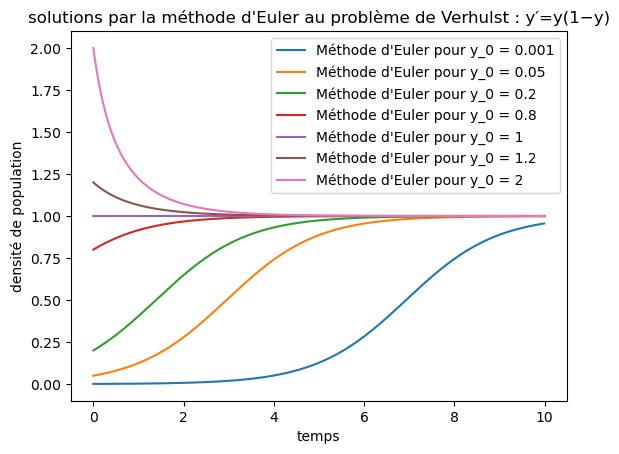

In [29]:
from math import *


for y_0 in [0.001,0.05,0.2,0.8,1,1.2,2]:
    N=1200
    h=10/N
    x=np.arange(0,10,h)
    y=[y_0]
    for i in range(N-1):
        y.append(y[i]+h*(y[i]-y[i]**2))
    plt.plot(x,y,label="Méthode d'Euler pour y_0 = "+str(y_0))
    

plt.legend()
plt.title("solutions par la méthode d'Euler au problème de Verhulst : y′=y(1−y)")
plt.ylabel("densité de population")
plt.xlabel("temps")
plt.show()

**-> INTERPRETATION**
On constate que la solution constante égale à 1 est solution et sépare deux domaines avec des régimes de solutions différents :
pour y_0>1, la densité de population est trop élevée : manque de ressources, épidémie se propagent plus facilement... La densité de population décroit ainsi en tendant vers une densité de 1, correspondant à un état d'équilibre lié à la capacité de l'écosystème de la population
pour y_0<1, la densité de population est assez faible pour permettre une croissance de la pupulation, on observe sur la courbe y_0=0.001 que dans un premier temps la densité de population croit exponentiellement (partie convexe de la courbe ) jusqu'a avoir atteint un seuil de croissance, puis continue plus faiblement (partie concave) pour tendre vers une densité de 1, correspondant à un état d'équilibre lié à la capacité de l'écosystème de la population

## Exercice 2. Modèle non uniforme en espace

On suppose maintenant que nos poissons, en plus de naître et mourir, peuvent également se déplacer le long du canal. On s'attend alors à deux phénomènes : 
1. La population de poissons est susceptible d'évoluer en un point donné vers un état d'équilibre lié à la capacité locale de l'environnement (nourriture plus ou moins abondante, dangers plus ou moins présents). 
2. Les poissons évitent d'être trop nombreux dans un même espace, ils ont tendance à se répartir vers les zones moins peuplées (on parle d'un phénomène de "diffusion").


**Formalisation du problème**

On note maintenant $y(t,x)$ la densité de population au point $x$ et à l'instant $t$. On propose dans un premier temps de représenter les phénomènes 1 et 2 ci-dessus par l'équation aux dérivées partielles suivante :

$$
\frac{\partial y(t,x)}{\partial t}=\eta\frac{\partial ^2y(t,x)}{\partial x^2} + y(t,x)(b(x)-y(t,x)),
$$

avec les conditions au bord périodiques $y(t,0)=y(t,1)$ pour tout $t\geq 0$ et la donnée initiale $y(0,x)= y_0(x)$, 
la fonction $y_0$ étant supposée donnée.

Ici, $b(x)$ est une fonction de l'espace qui détermine les contraintes locales au point $x$ pour la survie des individus. On appelle *terme source* le terme $y(t,x)(b(x)-y(t,x))$ dans l'équation ci-dessus, déjà rencontré dans le modèle de Verhulst pour $b=1$.

On va donc désormais chercher à approcher les solutions de ce problème.


**Discrétisation en espace**

En guise de discrétisation en espace du problème, on procède par différences finies avec un pas $\Delta x=1/N_x$. Une version intermédiaire du problème est ainsi constitué d'un problème dit semi-discret, en l'occurence un système d'équations différentielles posé dans $\mathbb{R}^{N_x}$ :

$$
U'(t)=-\eta AU(t)+F(U(t)),
$$

où l'on note $U(t)=(u_i(t))_{0\leq i\leq N_x-1}$ tel que $u_i(t)$ approche $y(t,i\Delta x)$, et avec la condition de bord périodique $u_{N_x}(t)=u_1(t)$. La matrice $A$ symétrique est proche de celle déjà rencontrée maintes fois dans l'étude du laplacien 1D mais correspond à une variante avec conditions de bord périodiques :

$$
A=\frac1{\Delta x^2}\left(\begin{array}{cccccc}2& -1 & 0 & \cdots & 0 & -1 \\-1 & 2& -1 & 0 &  & 0 \\0 & \ddots & \ddots & \ddots & \ddots & \vdots \\\vdots & \ddots & -1 & 2& -1 & 0 \\0 &  & \ddots & \ddots & \ddots & -1 \\-1 & 0 & \cdots & 0 & -1 & 2\end{array}\right).
$$

La fonction $F:\mathbb{R}^{N_x}\to\mathbb{R}^{N_x}$ correspond au terme source.


**Discrétisation en temps**

L'EDO portant sur $U(t)=(u_i(t))_{0\leq i\leq N_x-1}$ est à son tour l'objet d'une discrétisation en temps, de pas $h$ comme on l'a vu dans l'exercice 1.

### Question 1 : Programmation et test de la méthode d'Euler explicite

On suppose que la population est initialement répartie uniformément dans deux foyers : l'un correspondant à l'intervalle $[0.2, 0.4]$ sur lequel on a une densité $y_0 = 1$ et l'autre correspondant à l'intervalle $[0.7,0.8]$ sur lequel on a une densité $y_0=0.5$.


Avec la méthode d'Euler explicite employée sur la formulation semi-discrète, résoudre sur l'intervalle de temps $[0,4]$ le problème ci-dessus avec cette donnée initiale

$$y_0(x) = 1_{[0.2,0.4]}(x) + 0.5 * 1_{[0.7,0.8]}(x),$$

la fonction d'équilibre

$$b(x)=0.1+0.9 \exp^{-100*(x-0.5)^2},$$

et le paramètre de diffusion $\eta=5.10^{-3}$.

Pour les paramètres numériques, on considérera dans cette question la dimension $N_x = 15$, et successivement les pas de temps $h=0.01$ puis $h=0.001$.  

Dans chacun des cas, tracer la solution numérique obtenue à l'instant final $T=4$. Les courbes correspondent-elles au résultat attendu ?

In [33]:
Nx=15
eta=5*(10**(-3))
A=2*np.eye(Nx)+np.diag(np.ones(Nx-1)*(-1),1)+np.diag(np.ones(Nx-1)*(-1),-1)+np.diag(np.ones(1)*(-1),Nx-1)+np.diag(np.ones(1)*(-1),-Nx+1)
T=4
y_0=[]
for e in [(15/Nx)*i for i in range(Nx+1)]:
    if e>=0.2 and e<=0.4:
        y_0.append(1)
    if e>=0.7 and e<=0.8:
        y_0.append(0.5)
    else:
        y_0.append(0)

def F(y):
    #ici changer le x proprement
    return y*(0.1+0.9*exp(-100∗(𝑥−0.5)**2)-y)
F=np.vectorize(F)
    
    
h=0.01
N=floor(4/0.01)
x=np.arrange(0,T,h)
y=[y_0]
for i in range(N):
    y.append(y[i]+h*(-eta*np.dot(A,y[i])+F(y[i])))




SyntaxError: invalid character '−' (U+2212) (2285162742.py, line 15)

**-> INTERPRETATION**

### Question 2 : Résolution au fil du temps

On prendra désormais $N_x=50$ et $h=0.01$. 
Tracer sur un même graphe les courbes représentant la densité de population en 10 instants $t$ uniformément répartis entre 0 et 4.  

Commenter.  

On pourra dans un deuxième temps représenter la solution en fonction de $x$ et $t$ par un champ de couleur à l'aide d'une commande de la forme `plt.imshow(U.T, extent=[0,1,0,4], origin='lower', aspect='auto' )`, où `U` désigne le numpyarray 2D (en fonction de $x$ et $t$) comprenant la solution.

**-> INTERPRETATION**

### Question 3 : Instabilité numérique

Reprendre la question précédente avec un nombre supérieur de points en espace égal à $N_x=100$, puis à $N_x=101$, un pas de temps maintenu à $h=0.01$ et un temps final de simulation de $T=2$. Qu'observe-t-on numériquement ?

### Question 4 : Résolution par méthode d'Euler implicite

Toujours pour $N_x=100$ et le pas de temps $h=0.01$, résoudre jusqu'à l'instant $T=4$ le même problème avec une implicitation du terme de diffuion, le terme source étant maintenu sous une forme explicite.

$$\forall i \in \mathbb{N},\quad U_{j+1} = U_{j} - h \eta A U_{j+1} + h F(U_j).$$

Commenter les courbes obtenues.

**-> INTERPRETATION**